# Linear Regression


In [12]:
import matplotlib.pyplot as plt

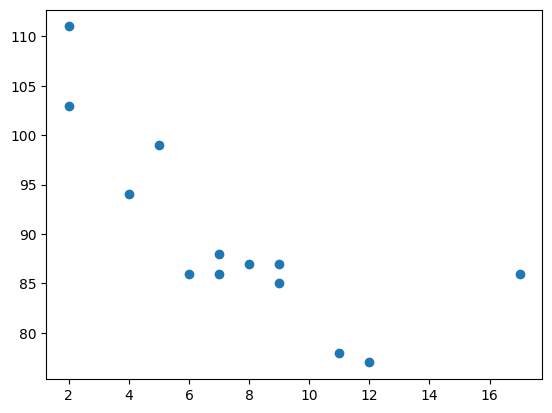

In [13]:
x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y = [99,86,87,88,111,86,103,87,94,78,77,85,86]

plt.scatter(x, y)
plt.show() 

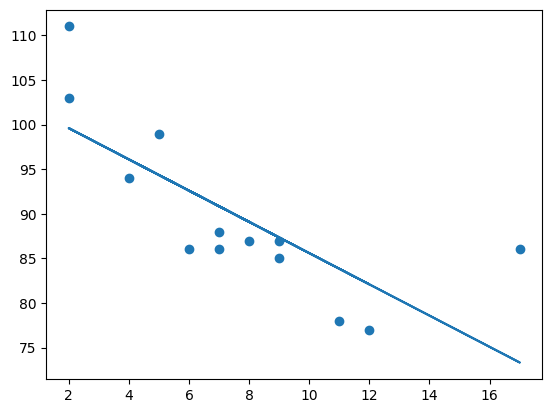

In [14]:
# Import stats module from scipy
# Used for statistical functions like correlation, regression, etc.
from scipy import stats


# Independent variable (input feature)
# Example: age, experience, size, etc.
x = [5,7,8,7,2,17,2,9,4,11,12,9,6]

# Dependent variable (target/output)
# Example: salary, marks, price, etc.
y = [99,86,87,88,111,86,103,87,94,78,77,85,86]


# Perform simple linear regression
# Returns:
# m       -> slope (coefficient)
# c       -> intercept
# r       -> correlation coefficient
# p       -> p-value
# std_err -> standard error
m, c, r, p, std_err = stats.linregress(x, y)


# Create a function for the regression equation
# Equation: y = mx + c
def myfunc(x):
    return m * x + c


# Apply the regression equation to all x values
# Generates predicted y values
model = list(map(myfunc, x))


# Plot original data points
plt.scatter(x, y)


# Plot regression line
plt.plot(x, model)


# Display the graph
plt.show()

In [15]:
# Call the regression function with x = 10
# It calculates the predicted value using the equation:
# y = m*x + c
speed = myfunc(10)

# Print the predicted value
print(speed)

85.59308314937454


# Polynomial Regression


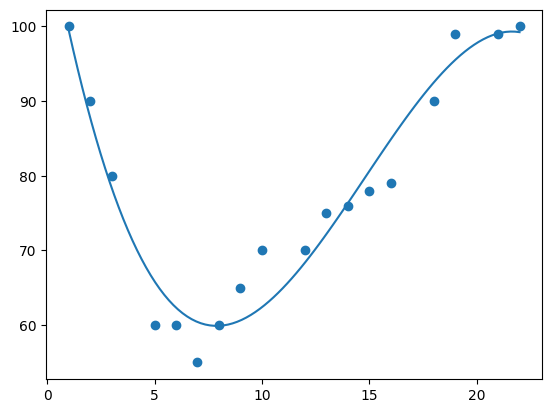

In [ ]:
# Import NumPy library
# Used for mathematical operations and polynomial functions
import numpy as np

# Import Matplotlib for plotting graphs
import matplotlib.pyplot as plt


# Input feature values (X)
# Example: experience, age, time, etc.
x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]

# Output/target values (Y)
# Example: salary, marks, price, etc.
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]


# Fit a polynomial curve of degree 3 (cubic polynomial)
# Syntax:
# np.polyfit(X, Y, degree)
#
# Parameters:
# X      -> Input values
# Y      -> Target values
# degree -> Degree of polynomial
#
# Returns:
# Polynomial coefficients
#
# np.poly1d() converts these coefficients into a polynomial function
mymodel = np.poly1d(np.polyfit(x, y, 3))


# Create 100 equally spaced points
# between 1 and 22 for a smooth curve
#
# Syntax:
# np.linspace(start, stop, number_of_points)
#
# start  -> Starting value
# stop   -> Ending value
# 100    -> Total points to generate
myline = np.linspace(1, 22, 100)


# Plot original data points
#
# Syntax:
# plt.scatter(X, Y)
plt.scatter(x, y)


# Plot the polynomial curve
#
# mymodel(myline)
# means:
# pass all 100 values into the polynomial equation
# and get predicted Y values
#
# Syntax:
# plt.plot(X_values, Y_values)
plt.plot(myline, mymodel(myline))


# Display the graph
plt.show()

## R-Squared

###  R² score measures how well the regression model fits the data (0 = poor fit, 1 = perfect fit)


In [26]:
from sklearn.metrics import r2_score

x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]

mymodel = np.poly1d(np.polyfit(x, y, 3))

# Calculate R² score
#
# Syntax:
# r2_score(actual_values, predicted_values)
#
# y          -> actual values
# mymodel(x) -> predicted values generated by the polynomial model
#
# Returns a value between 0 and 1 (usually)
print(r2_score(y, mymodel(x)))

0.9432150416451026


## Predict Future Values

In [28]:
# Create a degree-3 polynomial regression model
mymodel = np.poly1d(np.polyfit(x, y, 3))

# Predict the output value for x = 17
# Formula used:
# y = a₃x³ + a₂x² + a₁x + a₀
speed = mymodel(17)

# Print the predicted value
print(speed)

88.87331269698001


## Bad Fit?

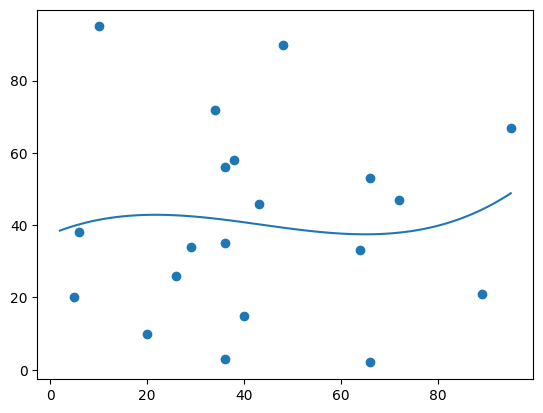

In [32]:
# Input feature values (X)
x = [89,43,36,36,95,10,66,34,38,20,26,29,48,64,6,5,36,66,72,40]

# Target/output values (Y)
y = [21,46,3,35,67,95,53,72,58,10,26,34,90,33,38,20,56,2,47,15]


# Create a Polynomial Regression model of degree 3
# Formula:
# y = a₃x³ + a₂x² + a₁x + a₀
# polyfit() finds the best polynomial equation
# poly1d() converts the equation into a prediction model
mymodel = np.poly1d(np.polyfit(x, y, 3))


# Generate 100 equally spaced X values
# Used to draw a smooth polynomial curve
myline = np.linspace(2, 95, 100)


# Plot the original data points
plt.scatter(x, y)


# Plot the polynomial regression curve
# mymodel(myline) generates predicted Y values
# for all X values in myline
plt.plot(myline, mymodel(myline))


# Display the graph
plt.show()


# Why is this a bad fit?
# ---------------------------------
# 1. The X and Y values do not have a clear pattern.
# 2. Y values change randomly as X increases.
# 3. The polynomial curve cannot properly follow the data points.
# 4. The R² score will be very low (close to 0 or negative).
# 5. A low R² score indicates a weak or no relationship between X and Y.
#
# To check whether the fit is good or bad:
# from sklearn.metrics import r2_score
# print(r2_score(y, mymodel(x)))
#
# R² ≈ 1  -> Good fit
# R² ≈ 0  -> Bad fit
# R² < 0  -> Very bad fit

# Clear pattern + High R²  -> Good fit
# Random pattern + Low R² -> Bad fit

In [33]:
mymodel = np.poly1d(np.polyfit(x, y, 3))
print(r2_score(y, mymodel(x)))

0.009952707566680652


# Multiple Regression

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [6]:
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns = iris.feature_names
)

In [7]:
# Select input features
X = df[['sepal length (cm)', 'sepal width (cm)']]

# Select target
y = df['petal length (cm)']

# Create Linear Regression model
lr = LinearRegression()

# Train the model
lr.fit(X, y)

# Predict
y_pred = lr.predict([[5.1, 3.5]])

print(y_pred)

[1.84557896]


c:\Users\harsh\Desktop\Saloni\ml\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Coefficient

### The coefficient is a factor that describes the relationship with an unknown variable.

### Example: if x is a variable, then 2x is x two times. x is the unknown variable, and the number 2 is the coefficient.

In [8]:
print(lr.coef_)

[ 1.77559255 -1.33862329]
